In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import statsmodels as sms

Uploading the cleaned file

In [2]:
data = pd.read_csv('../data/processed/cleaned_healthcare_claims.csv')

In [3]:
data.count()

Provider_ID                              10000
Claim_ID                                 10000
Patient_Age                              10000
Patient_Gender                           10000
Diagnosis_Code                           10000
Procedure_Code                           10000
Claim_Amount                             10000
Approved_Amount                          10000
Insurance_Type                           10000
Claim_Submission_Date                    10000
Days_Between_Service_and_Claim           10000
Number_of_Claims_Per_Provider_Monthly    10000
Provider_Specialty                       10000
Patient_State                            10000
Claim_Status                             10000
Is_Fraud                                 10000
Length_of_Stay                           10000
Visit_Type                               10000
Chronic_Condition_Flag                   10000
Prior_Visits_12m                         10000
dtype: int64

In this file we will answer the following questions from our cleaned dataset. 

1. Univariate Analysis 

The Goal: 

Define baseline norms, understand distributions, and identify data anomalies in single columns.

- Numerical Columns (Histograms & Boxplots)

✅ What is the standard cost profile of claims in our system? (Mean vs. Median Claim_Amount)

✅ What does a typical length of hospital stay look like? (Length_of_Stay distribution)

✅ Are patient ages skewed toward a specific demographic, like elderly or pediatric care? (Patient_Age distribution)

✅ What are the statistical upper bounds for costs before a claim is flagged as an extreme outlier? (IQR / Z-Score cutoffs)

UNIVARIATE ANALYSIS for Numeric Columns

First of all, let's perform a quick univariate analysis on all numeric columns using for loop. 

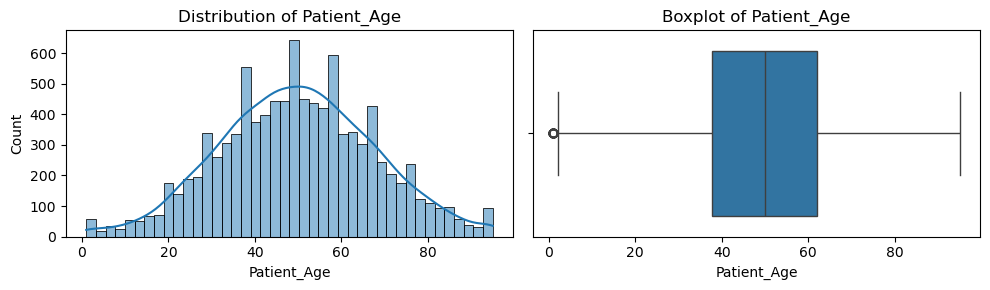

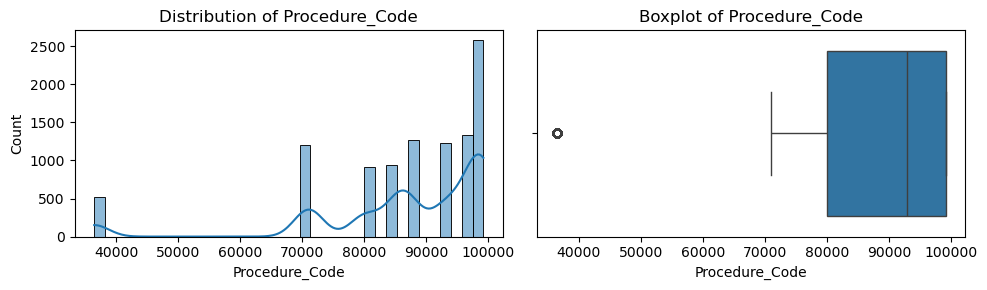

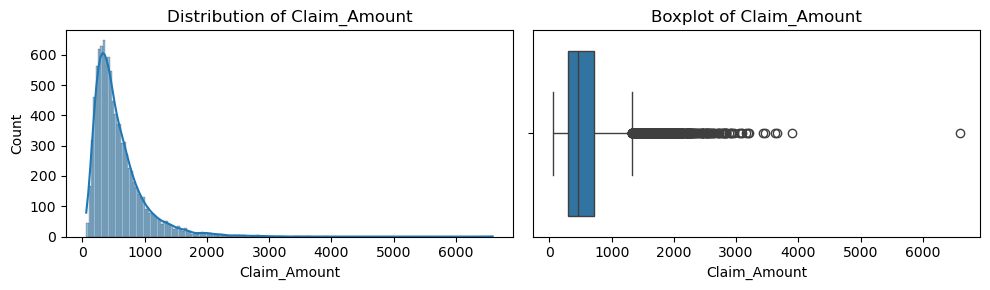

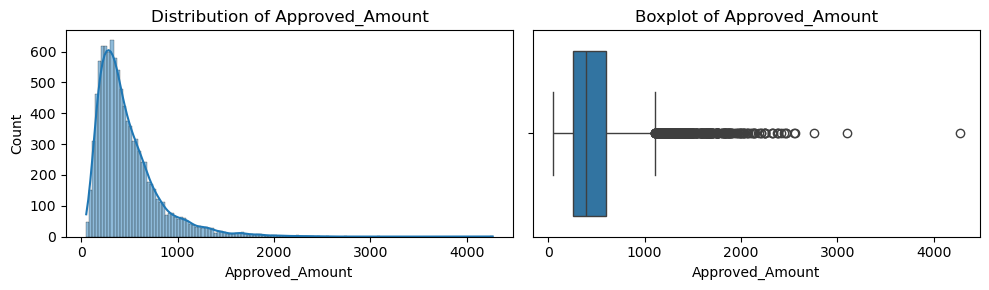

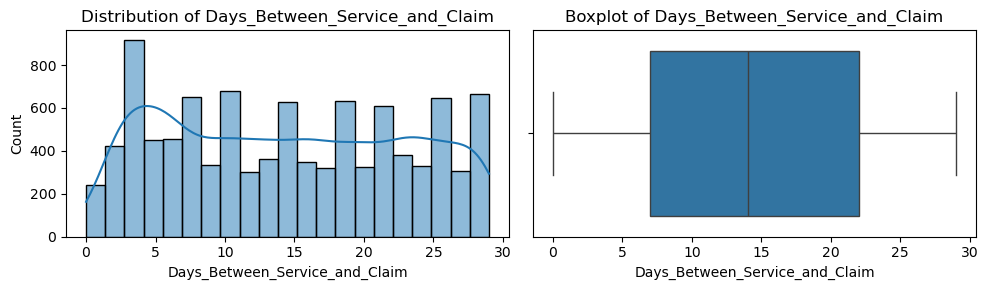

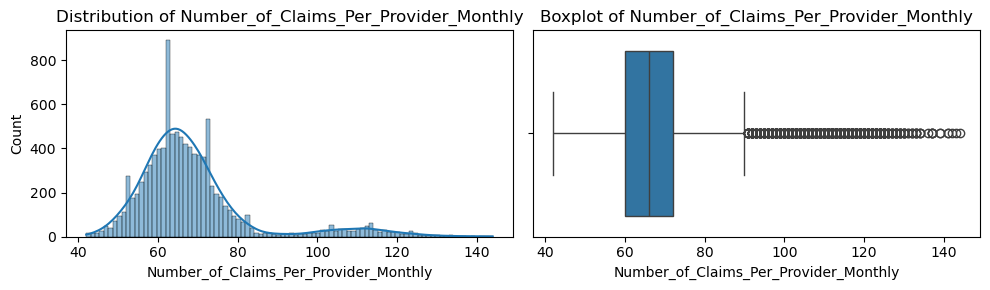

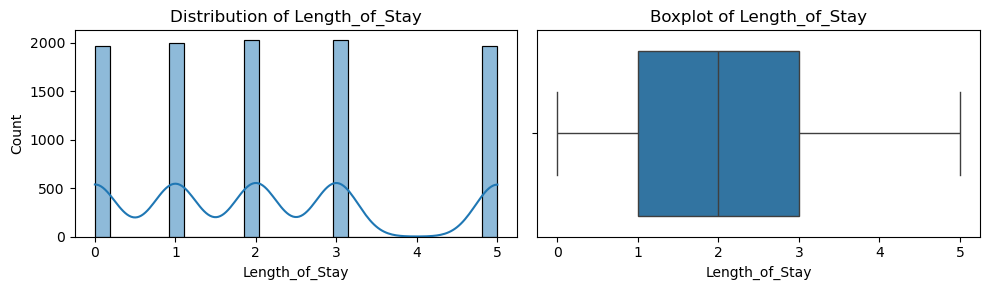

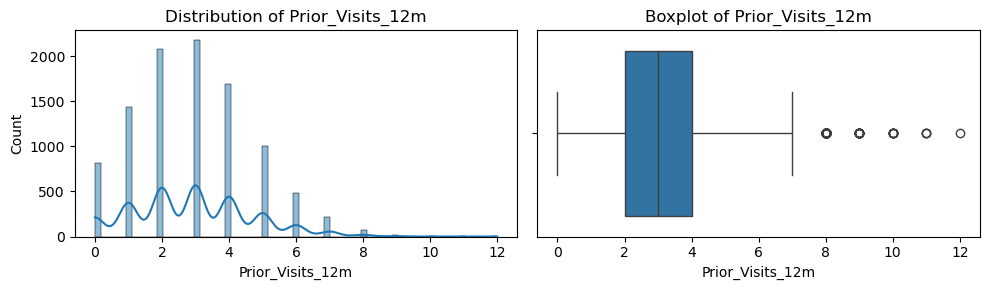

In [4]:
num_col = data.select_dtypes(include=['Int64', 'float']).columns

for col in num_col:
    plt.figure(figsize=(10,3))

    plt.subplot(1,2,1)
    sns.histplot(data[col], kde = True)
    plt.title(f"Distribution of {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x = data[col])
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

What is the standard cost profile of claims in our system? (Mean vs. Median Claim_Amount)

In [5]:
mean_cost = data['Claim_Amount'].mean()
median_cost = data['Claim_Amount'].median()
skewness_cost = data['Claim_Amount'].skew()

print("Claim Amount Profile")
print(f"Mean Cost of Claim Amount: ${mean_cost:,.2f}")
print(f"Median Cost of Claim Amount: ${median_cost:,.2f}")
print(f"Skewness Cost of Claim Amount: ${skewness_cost:,.2f}(Right Skewed if > 0)\n")

Claim Amount Profile
Mean Cost of Claim Amount: $572.80
Median Cost of Claim Amount: $461.23
Skewness Cost of Claim Amount: $2.41(Right Skewed if > 0)



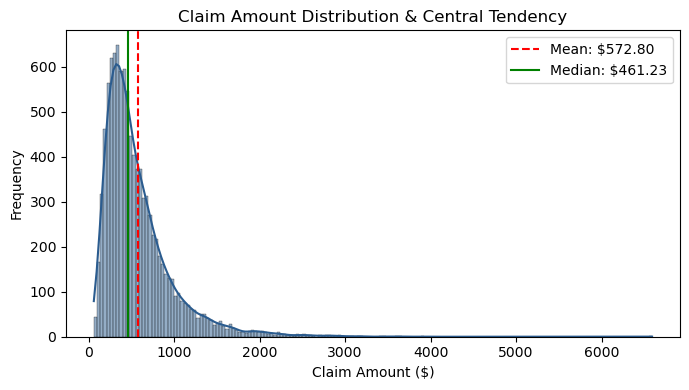

In [6]:
plt.figure(figsize=(7, 4))
sns.histplot(data['Claim_Amount'], kde=True, color='#2b5c8f')
plt.axvline(mean_cost, color='red', linestyle='--', label=f'Mean: ${mean_cost:,.2f}')
plt.axvline(median_cost, color='green', linestyle='-', label=f'Median: ${median_cost:,.2f}')
plt.title('Claim Amount Distribution & Central Tendency')
plt.xlabel('Claim Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

What does a typical length of hospital stay look like? (Length_of_Stay distribution)

In [7]:
mean_stay = data['Length_of_Stay'].mean()
median_stay = data['Length_of_Stay'].median()
mode_stay = data['Length_of_Stay'].mode()[0]

print(f"Typical Length of Stay in Hospital Looks Like")
print(f"Average Length of Stay: {mean_stay:.1f} days")
print(f"Median Length of Stay: {median_stay:.1f} days")
print(f"Most Frequent Stay (Mode): {mode_stay:.0f} days\n")

Typical Length of Stay in Hospital Looks Like
Average Length of Stay: 2.2 days
Median Length of Stay: 2.0 days
Most Frequent Stay (Mode): 3 days



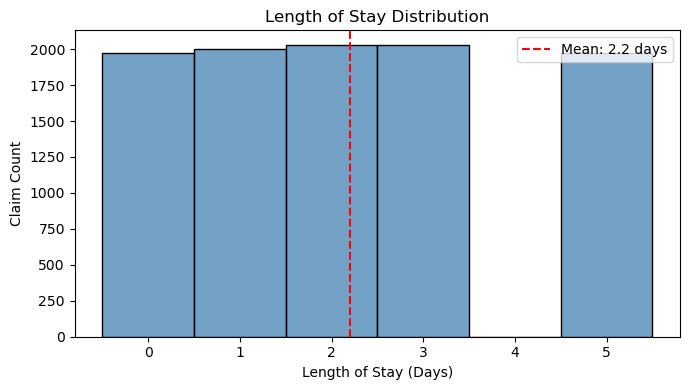

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(data['Length_of_Stay'], discrete=True, color='#4682b4')
plt.axvline(mean_stay, color='red', linestyle='--', label=f'Mean: {mean_stay:.1f} days')
plt.title('Length of Stay Distribution')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Claim Count')
plt.legend()
plt.tight_layout()
plt.show()

Are patient ages skewed toward a specific demographic, like elderly or pediatric care? (Patient_Age distribution)

In [9]:
age_min = data['Patient_Age'].min()
age_max = data['Patient_Age'].max()
age_mean = data['Patient_Age'].mean()
elderly_pct = (data['Patient_Age'] >= 65).mean() * 100

print("--- Question 3: Demographic Breakdown ---")
print(f"Age Range: {age_min} to {age_max} years")
print(f"Average Patient Age: {age_mean:.1f} years")
print(f"Percentage of Senior Patients (65+): {elderly_pct:.2f}%\n")

--- Question 3: Demographic Breakdown ---
Age Range: 1 to 95 years
Average Patient Age: 49.8 years
Percentage of Senior Patients (65+): 20.81%



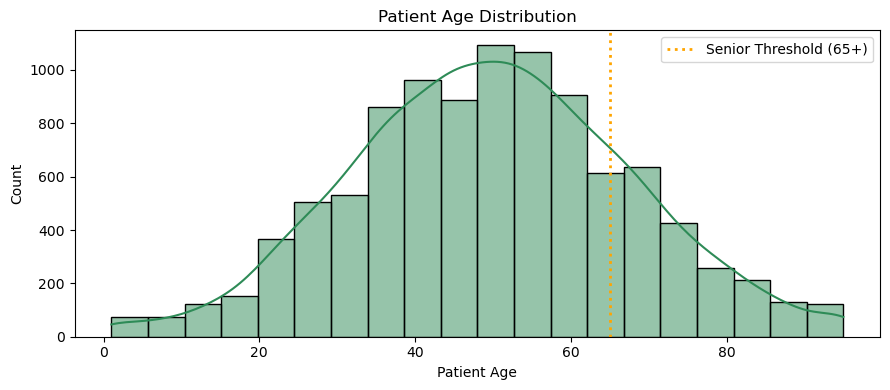

In [10]:
plt.figure(figsize=(9, 4))
sns.histplot(data['Patient_Age'], kde=True, bins=20, color='#2e8b57')
plt.axvline(65, color='orange', linestyle=':', linewidth=2, label='Senior Threshold (65+)')
plt.title('Patient Age Distribution')
plt.xlabel('Patient Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

What are the statistical upper bounds for costs before a claim is flagged as an extreme outlier? (IQR / Z-Score cutoffs)

In [11]:
Q1 = data['Claim_Amount'].quantile(0.25)
Q3 = data['Claim_Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound_iqr = Q3 + (1.5 * IQR)

std_cost = data['Claim_Amount'].std()
upper_bound_zscore = mean_cost + (3 * std_cost)

outliers_iqr_count = (data['Claim_Amount'] > upper_bound_iqr).sum()

print("--- Question 4: Outlier Upper Bounds ---")
print(f"IQR Upper Threshold (Q3 + 1.5*IQR): ${upper_bound_iqr:,.2f}")
print(f"Z-Score Upper Threshold (Mean + 3*STD): ${upper_bound_zscore:,.2f}")
print(f"Total Claims Exceeding IQR Boundary: {outliers_iqr_count} claims")

--- Question 4: Outlier Upper Bounds ---
IQR Upper Threshold (Q3 + 1.5*IQR): $1,320.61
Z-Score Upper Threshold (Mean + 3*STD): $1,791.41
Total Claims Exceeding IQR Boundary: 552 claims


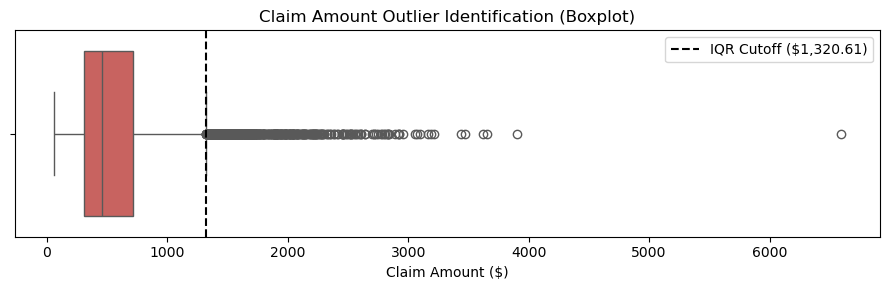

In [12]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=data['Claim_Amount'], color='#d9534f')
plt.axvline(upper_bound_iqr, color='black', linestyle='--', label=f'IQR Cutoff (${upper_bound_iqr:,.2f})')
plt.title('Claim Amount Outlier Identification (Boxplot)')
plt.xlabel('Claim Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

- Categorical Columns (Bar Charts & Frequencies)

What is the baseline overall fraud rate across the entire dataset? 

In [13]:
total_claims = len(data)
fraud_claims = data['Is_Fraud'].sum()
baseline_fraud_rate = (fraud_claims / total_claims) * 100

print("--- Question 1: Baseline Dataset Fraud Rate ---")
print(f"Total Claims: {total_claims:,}")
print(f"Total Fraudulent Claims: {fraud_claims:,}")
print(f"Baseline Fraud Rate: {baseline_fraud_rate:.2f}%\n")

--- Question 1: Baseline Dataset Fraud Rate ---
Total Claims: 10,000
Total Fraudulent Claims: 829
Baseline Fraud Rate: 8.29%



C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\1396725222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='Is_Fraud', palette=['#2b5c8f', '#d9534f'])


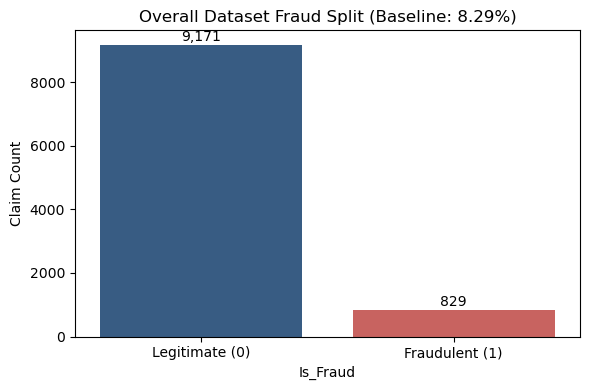

In [14]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x='Is_Fraud', palette=['#2b5c8f', '#d9534f'])
plt.title(f'Overall Dataset Fraud Split (Baseline: {baseline_fraud_rate:.2f}%)')
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.ylabel('Claim Count')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 3),
                textcoords='offset points')
plt.tight_layout()
plt.show()

Which medical specialties generate the highest volume of total claims? (Provider_Specialty counts)

In [15]:
specialty_counts = data['Provider_Specialty'].value_counts()
specialty_pcts = data['Provider_Specialty'].value_counts(normalize=True) * 100

specialty_df = pd.DataFrame({
    'Total_Claims': specialty_counts,
    'Percentage_Share': specialty_pcts
})

print("--- Question 2: Top Provider Specialties by Volume ---")
print(specialty_df)
print("\n")

--- Question 2: Top Provider Specialties by Volume ---
                    Total_Claims  Percentage_Share
Provider_Specialty                                
Internal Medicine           2329             23.29
General Practice            1918             19.18
Orthopedics                 1616             16.16
Neurology                   1516             15.16
Cardiology                  1366             13.66
Pulmonology                 1255             12.55




C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\2354076680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=specialty_counts.values, y=specialty_counts.index, palette='Blues_r')


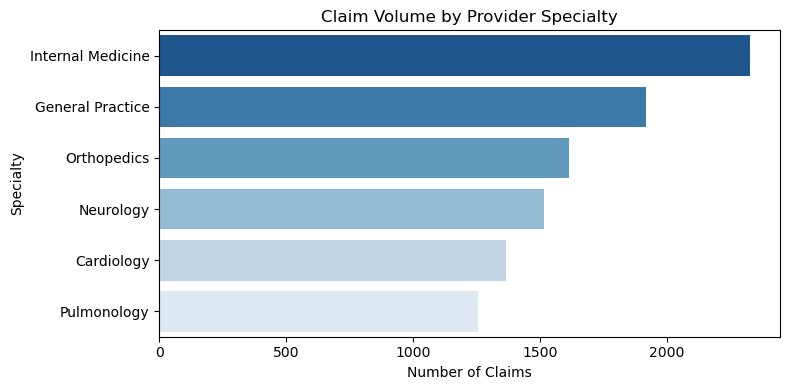

In [16]:
plt.figure(figsize=(8, 4))
sns.barplot(x=specialty_counts.values, y=specialty_counts.index, palette='Blues_r')
plt.title('Claim Volume by Provider Specialty')
plt.xlabel('Number of Claims')
plt.ylabel('Specialty')
plt.tight_layout()
plt.show()


What are the most common diagnosis codes submitted? (Diagnosis_Code frequency)

In [17]:
top_diagnosis = data['Diagnosis_Code'].value_counts().head(5)
top_diagnosis_pct = (top_diagnosis / total_claims) * 100

diagnosis_df = pd.DataFrame({
    'Claim_Count': top_diagnosis,
    'Percentage_Share': top_diagnosis_pct
})

print("--- Question 3: Top 5 Most Common Diagnosis Codes ---")
print(diagnosis_df)
print("\n")

--- Question 3: Top 5 Most Common Diagnosis Codes ---
                Claim_Count  Percentage_Share
Diagnosis_Code                               
M54.5                  1055             10.55
E78.5                  1027             10.27
E11.9                  1026             10.26
I25.10                 1025             10.25
N39.0                  1016             10.16




C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\1118651056.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_diagnosis.values, y=top_diagnosis.index, palette='Greens_r')


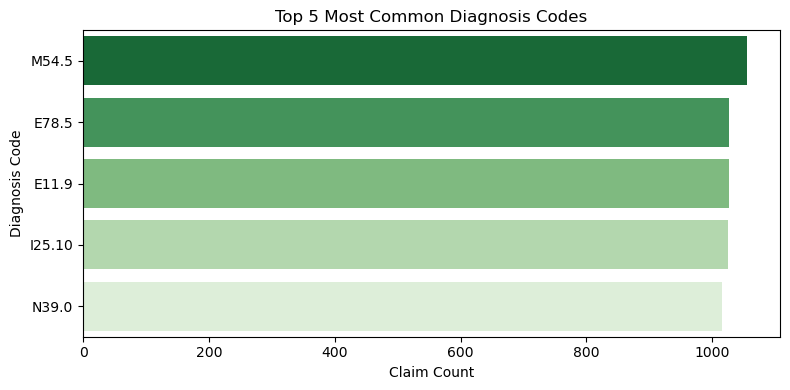

In [18]:
plt.figure(figsize=(8, 4))
sns.barplot(x=top_diagnosis.values, y=top_diagnosis.index, palette='Greens_r')
plt.title('Top 5 Most Common Diagnosis Codes')
plt.xlabel('Claim Count')
plt.ylabel('Diagnosis Code')
plt.tight_layout()
plt.show()

How are claims split by insurance policy types? (Insurance_Type proportion)

In [19]:
insurance_counts = data['Insurance_Type'].value_counts()
insurance_pcts = data['Insurance_Type'].value_counts(normalize=True) * 100

insurance_df = pd.DataFrame({
    'Total_Claims': insurance_counts,
    'Percentage_Share': insurance_pcts
})

print("--- Question 4: Distribution Across Insurance Types ---")
print(insurance_df)

--- Question 4: Distribution Across Insurance Types ---
                Total_Claims  Percentage_Share
Insurance_Type                                
Medicare                2775             27.75
Medicaid                2419             24.19
Private                 2405             24.05
Self-Pay                2401             24.01


C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\1359925162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=insurance_counts.index, y=insurance_counts.values, palette='Purples_r')


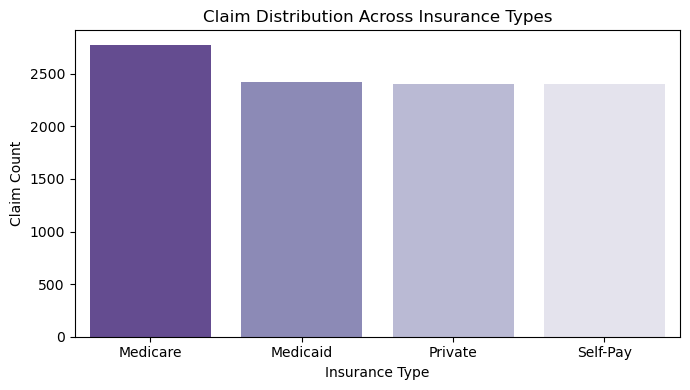

In [20]:
plt.figure(figsize=(7, 4))
sns.barplot(x=insurance_counts.index, y=insurance_counts.values, palette='Purples_r')
plt.title('Claim Distribution Across Insurance Types')
plt.xlabel('Insurance Type')
plt.ylabel('Claim Count')
plt.tight_layout()
plt.show()

2. Bivariate Analysis

The Goal: Compare features directly against each other or against the target variable (Is_Fraud) to find initial red flags.

- Numerical vs. Target (Is_Fraud)

Do fraudulent claims have significantly higher dollar amounts than legitimate ones? (Claim_Amount vs. Is_Fraud)

Are longer hospital stays correlated with fraudulent billing? (Length_of_Stay vs. Is_Fraud)

- Categorical vs. Target (Is_Fraud)

Which provider specialties have the highest proportion of fraud flags? (Provider_Specialty vs. Is_Fraud)

Are certain diagnosis codes disproportionately associated with fraudulent claims? (Diagnosis_Code vs. Is_Fraud)

Do specific insurance plans suffer higher fraud rates than others? (Insurance_Type vs. Is_Fraud)

- Feature vs. Feature (Non-Target)

Are high claim amounts tied to patient age, or is high billing spread across all age groups? (Patient_Age vs. Claim_Amount)

Is there a strong correlation between length of stay and approved payout amounts? (Length_of_Stay vs. Approved_Amount)

In [21]:
sns.set_theme(style="whitegrid")

baseline_fraud_rate = (data['Is_Fraud'].sum() / len(data)) * 100

Do fraudulent claims have significantly higher dollar amounts than legitimate ones? (Claim_Amount vs. Is_Fraud)

In [22]:
print("--- Question 1: Claim Amount vs. Is_Fraud ---")

amount_stats = data.groupby('Is_Fraud')['Claim_Amount'].agg(
    Mean='mean',
    Median='median',
    Std_Dev='std',
    Max='max'
).reset_index()

print(amount_stats)
print("\n")

--- Question 1: Claim Amount vs. Is_Fraud ---
   Is_Fraud        Mean  Median     Std_Dev      Max
0     False  535.008352  442.88  352.694113  3162.93
1      True  990.931797  831.16  651.195924  6590.70




C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\2691772582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Is_Fraud', y='Claim_Amount', palette=['#2b5c8f', '#d9534f'])


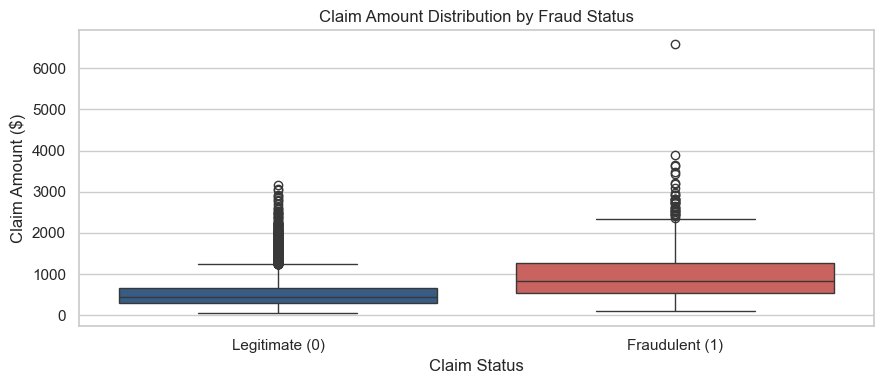

In [23]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=data, x='Is_Fraud', y='Claim_Amount', palette=['#2b5c8f', '#d9534f'])
plt.title('Claim Amount Distribution by Fraud Status')
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.xlabel('Claim Status')
plt.ylabel('Claim Amount ($)')
plt.tight_layout()
plt.show()

Question 2: Are longer hospital stays correlated with fraudulent billing?

In [24]:
print("--- Question 2: Length of Stay vs. Is_Fraud ---")
stay_stats = data.groupby('Is_Fraud')['Length_of_Stay'].agg(
    Mean_Days= "mean",
    Median_Days='median',
    Std_Dev='std'
).reset_index()

print(stay_stats)
print("\n")

--- Question 2: Length of Stay vs. Is_Fraud ---
   Is_Fraud  Mean_Days  Median_Days   Std_Dev
0     False   2.200087          2.0  1.705269
1      True   2.190591          2.0  1.767899




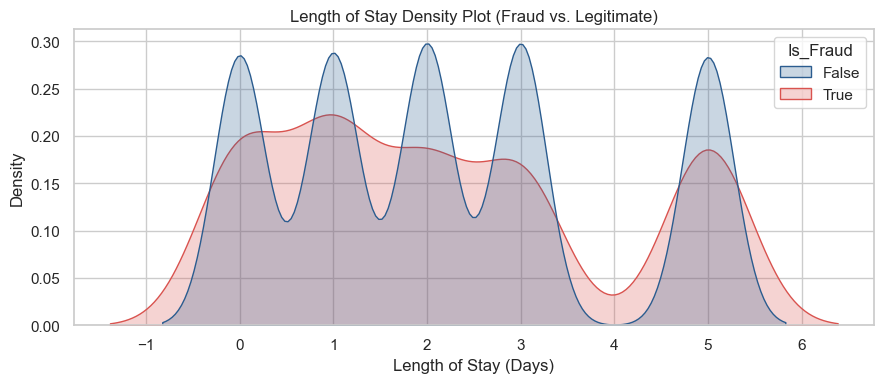

In [25]:
plt.figure(figsize=(9, 4))
sns.kdeplot(data=data, x='Length_of_Stay', hue='Is_Fraud', common_norm=False, palette=['#2b5c8f', '#d9534f'], fill=True)
plt.title('Length of Stay Density Plot (Fraud vs. Legitimate)')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Question 3: Which provider specialties have the highest proportion of fraud?

In [26]:
print("--- Question 3: Provider Specialty vs. Is_Fraud ---")
specialty_fraud = data.groupby('Provider_Specialty')['Is_Fraud'].agg(
    Total_Claims='count',
    Fraud_Claims='sum',
    Fraud_Rate=lambda x: x.mean() * 100
).reset_index().sort_values(by='Fraud_Rate', ascending=False)

print(specialty_fraud)
print("\n")

--- Question 3: Provider Specialty vs. Is_Fraud ---
  Provider_Specialty  Total_Claims  Fraud_Claims  Fraud_Rate
1   General Practice          1918           183    9.541189
2  Internal Medicine          2329           204    8.759124
4        Orthopedics          1616           138    8.539604
5        Pulmonology          1255            98    7.808765
0         Cardiology          1366           100    7.320644
3          Neurology          1516           106    6.992084




C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\2535428314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=specialty_fraud, x='Fraud_Rate', y='Provider_Specialty', palette='Reds_r')


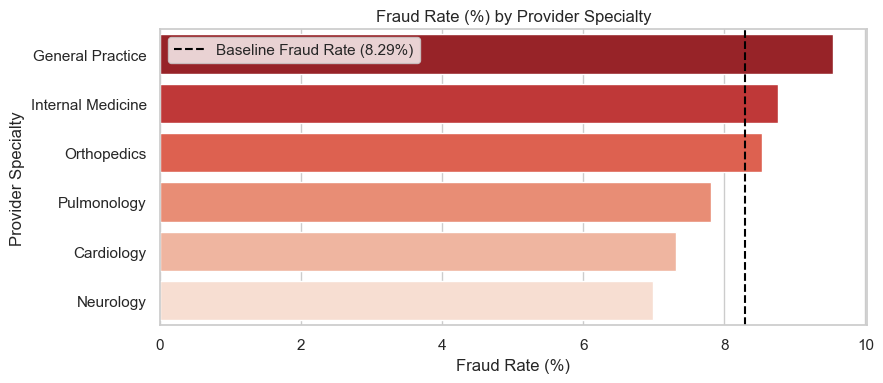

In [27]:
plt.figure(figsize=(9, 4))
sns.barplot(data=specialty_fraud, x='Fraud_Rate', y='Provider_Specialty', palette='Reds_r')
plt.axvline(baseline_fraud_rate, color='black', linestyle='--', label=f'Baseline Fraud Rate ({baseline_fraud_rate:.2f}%)')
plt.title('Fraud Rate (%) by Provider Specialty')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Provider Specialty')
plt.legend()
plt.tight_layout()
plt.show()

Question 4: Are certain diagnosis codes disproportionately associated with fraud?

In [28]:
print("--- Question 4: Top Diagnosis Codes vs. Is_Fraud ---")
# Analyze top 10 diagnosis codes by volume
top_10_diag = data['Diagnosis_Code'].value_counts().head(10).index
diag_data = data[data['Diagnosis_Code'].isin(top_10_diag)]

diag_fraud = diag_data.groupby('Diagnosis_Code')['Is_Fraud'].agg(
    Total_Claims='count',
    Fraud_Claims='sum',
    Fraud_Rate=lambda x: x.mean() * 100
).reset_index().sort_values(by='Fraud_Rate', ascending=False)

print(diag_fraud)
print("\n")

--- Question 4: Top Diagnosis Codes vs. Is_Fraud ---
  Diagnosis_Code  Total_Claims  Fraud_Claims  Fraud_Rate
4         I25.10          1025           102    9.951220
9          N39.0          1016            93    9.153543
3            I10           951            87    9.148265
6          J18.9           943            79    8.377519
1          E78.5          1027            86    8.373905
7          K21.9          1004            84    8.366534
5          J06.9           955            78    8.167539
8          M54.5          1055            83    7.867299
0          E11.9          1026            70    6.822612
2          F41.9           998            67    6.713427




C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\787083718.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_fraud, x='Diagnosis_Code', y='Fraud_Rate', palette='Reds_r')


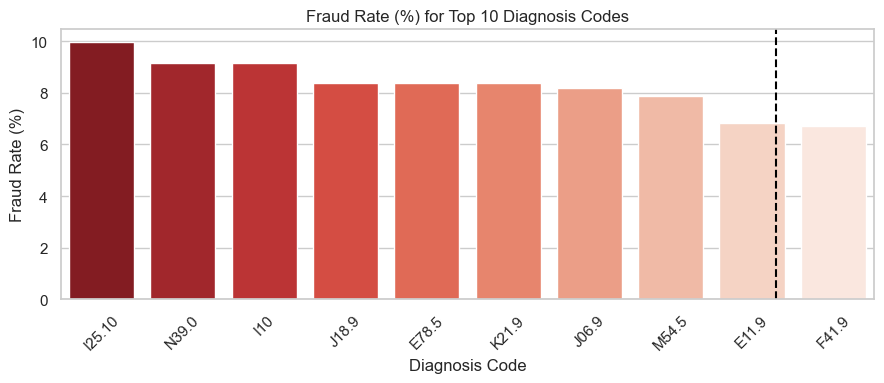

In [29]:
plt.figure(figsize=(9, 4))
sns.barplot(data=diag_fraud, x='Diagnosis_Code', y='Fraud_Rate', palette='Reds_r')
plt.axvline(baseline_fraud_rate, color='black', linestyle='--', label=f'Baseline ({baseline_fraud_rate:.2f}%)')
plt.title('Fraud Rate (%) for Top 10 Diagnosis Codes')
plt.xlabel('Diagnosis Code')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Question 5: Do specific insurance plans suffer higher fraud rates?

In [30]:
print("--- Question 5: Insurance Type vs. Is_Fraud ---")
insurance_fraud = data.groupby('Insurance_Type')['Is_Fraud'].agg(
    Total_Claims='count',
    Fraud_Claims='sum',
    Fraud_Rate=lambda x: x.mean() * 100
).reset_index().sort_values(by='Fraud_Rate', ascending=False)

print(insurance_fraud)
print("\n")

--- Question 5: Insurance Type vs. Is_Fraud ---
  Insurance_Type  Total_Claims  Fraud_Claims  Fraud_Rate
0       Medicaid          2419           202    8.350558
1       Medicare          2775           230    8.288288
3       Self-Pay          2401           199    8.288213
2        Private          2405           198    8.232848




C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\2391902158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=insurance_fraud, x='Insurance_Type', y='Fraud_Rate', palette='Oranges_r')


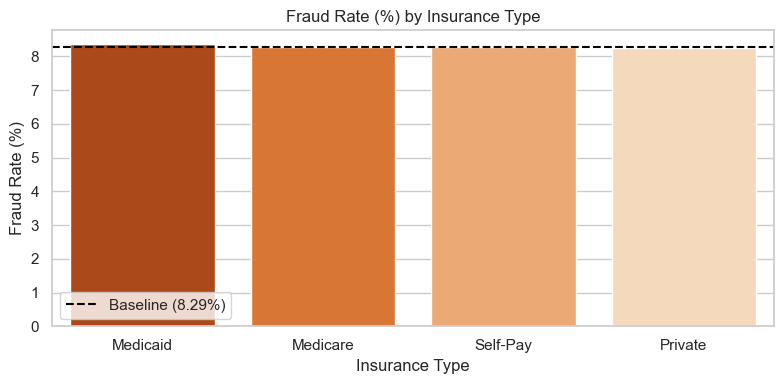

In [31]:
plt.figure(figsize=(8, 4))
sns.barplot(data=insurance_fraud, x='Insurance_Type', y='Fraud_Rate', palette='Oranges_r')
plt.axhline(baseline_fraud_rate, color='black', linestyle='--', label=f'Baseline ({baseline_fraud_rate:.2f}%)')
plt.title('Fraud Rate (%) by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

Question 6: Are high claim amounts tied to patient age?

In [32]:
print("--- Question 6: Patient Age vs. Claim Amount ---")
age_claim_corr = data['Patient_Age'].corr(data['Claim_Amount'])
print(f"Pearson Correlation (Age vs. Claim Amount): {age_claim_corr:.4f}\n")

--- Question 6: Patient Age vs. Claim Amount ---
Pearson Correlation (Age vs. Claim Amount): 0.0050



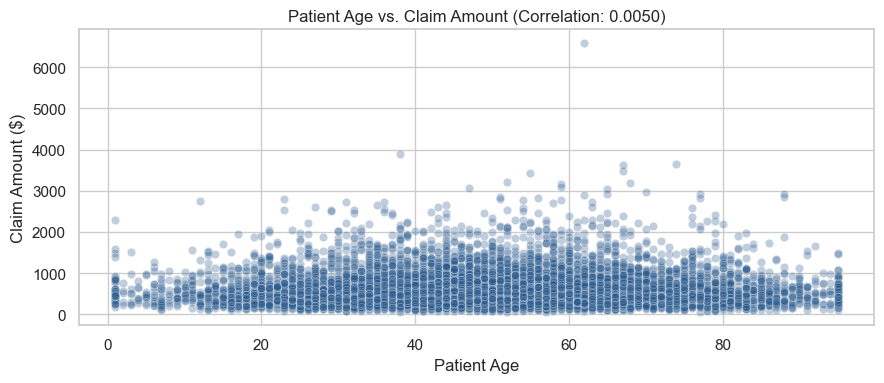

In [33]:
plt.figure(figsize=(9, 4))
sns.scatterplot(data=data, x='Patient_Age', y='Claim_Amount', alpha=0.3, color='#2b5c8f')
plt.title(f'Patient Age vs. Claim Amount (Correlation: {age_claim_corr:.4f})')
plt.xlabel('Patient Age')
plt.ylabel('Claim Amount ($)')
plt.tight_layout()
plt.show()

Question 7: Is length of stay correlated with approved payout amounts?

In [34]:
print("--- Question 7: Length of Stay vs. Approved Amount ---")
stay_approved_corr = data['Length_of_Stay'].corr(data['Approved_Amount'])
print(f"Pearson Correlation (Stay vs. Approved Amount): {stay_approved_corr:.4f}\n")

--- Question 7: Length of Stay vs. Approved Amount ---
Pearson Correlation (Stay vs. Approved Amount): 0.0122



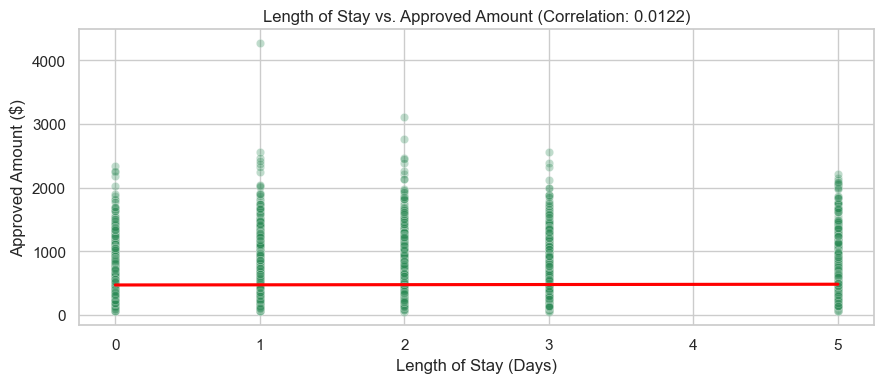

In [35]:
plt.figure(figsize=(9, 4))
sns.scatterplot(data=data, x='Length_of_Stay', y='Approved_Amount', alpha=0.3, color='#2e8b57')
sns.regplot(data=data, x='Length_of_Stay', y='Approved_Amount', scatter=False, color='red')
plt.title(f'Length of Stay vs. Approved Amount (Correlation: {stay_approved_corr:.4f})')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Approved Amount ($)')
plt.tight_layout()
plt.show()

3. Multivariate Analysis 

The Goal: Uncover hidden fraud patterns and complex interactions that simple pair plots miss.

Does the relationship between length of stay and claim amount change when comparing fraudulent vs. legitimate claims? (Length_of_Stay + Claim_Amount grouped by Is_Fraud)


In [36]:
# Create essential engineered features if not already present
if 'Payout_Ratio' not in data.columns:
    data['Payout_Ratio'] = data['Approved_Amount'] / data['Claim_Amount']

In [37]:
print("--- Question 1: Length of Stay vs. Claim Amount by Fraud Status ---")

# Summary stats across 3 dimensions
stay_cost_fraud = data.groupby('Is_Fraud')[['Length_of_Stay', 'Claim_Amount']].agg(['mean', 'median', 'std'])
print(stay_cost_fraud)
print("\n")

--- Question 1: Length of Stay vs. Claim Amount by Fraud Status ---
         Length_of_Stay                  Claim_Amount                    
                   mean median       std         mean  median         std
Is_Fraud                                                                 
False          2.200087    2.0  1.705269   535.008352  442.88  352.694113
True           2.190591    2.0  1.767899   990.931797  831.16  651.195924




In [38]:
# Calculate both the mean and standard deviation
mean_amount = data['Claim_Amount'].mean()
std_amount = data['Claim_Amount'].std()

print(f"Average Claim Amount: {mean_amount:.2f}")
print(f"Standard Deviation: {std_amount:.2f}")
print(f"Typical claims range between: {(mean_amount - std_amount):.2f} and {(mean_amount + std_amount):.2f}")


Average Claim Amount: 572.80
Standard Deviation: 406.20
Typical claims range between: 166.60 and 979.01



Are specific provider specialties abusing high-dollar billing codes for specific age groups? (Provider_Specialty + Patient_Age + Claim_Amount)



In [39]:
print("--- Question 2: Specialty, Patient Age, and Claim Amount Interaction ---")

# Grouping by Specialty and Age Group (Senior vs Non-Senior)
data['Age_Group'] = np.where(data['Patient_Age'] >= 65, 'Senior (65+)', 'Non-Senior (<65)')

specialty_age_billing = data.groupby(['Provider_Specialty', 'Age_Group', 'Is_Fraud'])['Claim_Amount'].agg(
    Avg_Claim='mean',
    Median_Claim='median',
    Claim_Count='count'
).reset_index()

print(specialty_age_billing.head(10))
print("\n")



--- Question 2: Specialty, Patient Age, and Claim Amount Interaction ---
  Provider_Specialty         Age_Group  Is_Fraud    Avg_Claim  Median_Claim  \
0         Cardiology  Non-Senior (<65)     False   543.740455       440.645   
1         Cardiology  Non-Senior (<65)      True   951.991647       833.460   
2         Cardiology      Senior (65+)     False   537.342662       460.680   
3         Cardiology      Senior (65+)      True   718.824000       777.000   
4   General Practice  Non-Senior (<65)     False   538.136637       452.515   
5   General Practice  Non-Senior (<65)      True  1028.113841       840.220   
6   General Practice      Senior (65+)     False   523.899537       430.270   
7   General Practice      Senior (65+)      True   987.741250       775.640   
8  Internal Medicine  Non-Senior (<65)     False   539.996454       444.120   
9  Internal Medicine  Non-Senior (<65)      True   927.958679       774.720   

   Claim_Count  
0          988  
1           85  
2     

C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\1405391643.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


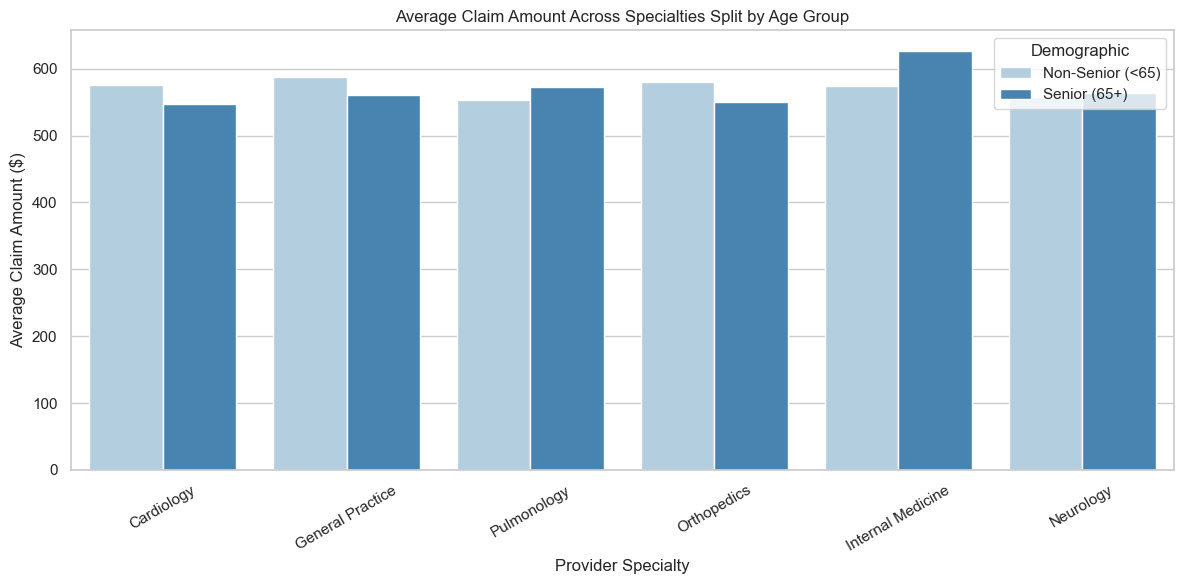

In [40]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=data, 
    x='Provider_Specialty', 
    y='Claim_Amount', 
    hue='Age_Group', 
    palette='Blues',
    ci=None
)
plt.title('Average Claim Amount Across Specialties Split by Age Group')
plt.xlabel('Provider Specialty')
plt.ylabel('Average Claim Amount ($)')
plt.xticks(rotation=30)
plt.legend(title='Demographic')
plt.tight_layout()
plt.show()

How do claim approval ratios (Approved_Amount / Claim_Amount) vary across different insurance types for fraudulent claims versus normal claims?

In [41]:
print("--- Question 3: Payout Ratio across Insurance Types by Fraud Status ---")

ratio_summary = data.groupby(['Insurance_Type', 'Is_Fraud'])['Payout_Ratio'].agg(
    Mean_Ratio='mean',
    Median_Ratio='median'
).reset_index()

print(ratio_summary)
print("\n")

--- Question 3: Payout Ratio across Insurance Types by Fraud Status ---
  Insurance_Type  Is_Fraud  Mean_Ratio  Median_Ratio
0       Medicaid     False    0.877671      0.880826
1       Medicaid      True    0.545304      0.538226
2       Medicare     False    0.876288      0.877889
3       Medicare      True    0.550163      0.542691
4        Private     False    0.874431      0.873564
5        Private      True    0.545687      0.536878
6       Self-Pay     False    0.875609      0.873337
7       Self-Pay      True    0.548291      0.552045




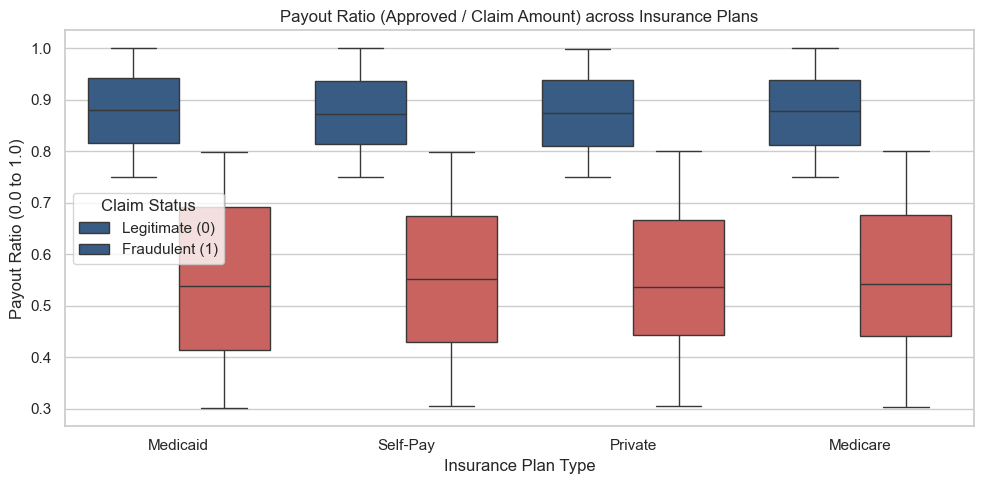

In [42]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=data, 
    x='Insurance_Type', 
    y='Payout_Ratio', 
    hue='Is_Fraud', 
    palette=['#2b5c8f', '#d9534f']
)
plt.title('Payout Ratio (Approved / Claim Amount) across Insurance Plans')
plt.xlabel('Insurance Plan Type')
plt.ylabel('Payout Ratio (0.0 to 1.0)')
plt.legend(title='Claim Status', labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.tight_layout()
plt.show()

--- Bonus: Overall Numerical Correlation Matrix ---


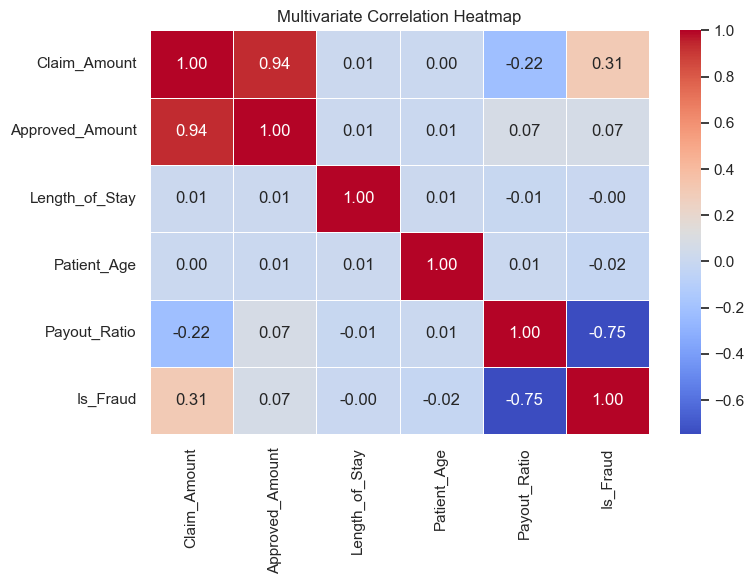

In [43]:
print("--- Bonus: Overall Numerical Correlation Matrix ---")

num_cols = ['Claim_Amount', 'Approved_Amount', 'Length_of_Stay', 'Patient_Age', 'Payout_Ratio', 'Is_Fraud']
corr_matrix = data[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Multivariate Correlation Heatmap')
plt.tight_layout()
plt.show()

4. Hypothesis Testing ($H_0$ vs $H_1$)

The Goal: Mathematically prove whether the patterns you saw in Bivariate and Multivariate analysis are statistically real or just random chance.

Business Question

       ↓

Hypothesis Formulation (H₀ / H₁)

       ↓

Select Statistical Test

       ↓

Run Test → Obtain p-value

       ↓

Evaluate Statistical & Practical Significance

       ↓
       
Business Action / Strategy

Core Hypothesis Testing Examples for Healthcare Fraud:

Question: Do high-volume or specific provider specialties have a higher fraud rate?

$H_0$ (Null): Fraud rate is identical across all provider specialties.

$H_1$ (Alternative): At least one provider specialty has a significantly different fraud rate.

Test: Chi-Square Test of Independence ($\chi^2$).

Question: Is the average claim amount for fraudulent claims significantly higher than for legitimate claims?

$H_0$ (Null): Mean Claim_Amount of Fraud = Mean Claim_Amount of Legitimate.

$H_1$ (Alternative): Mean Claim_Amount of Fraud $>$ Mean Claim_Amount of Legitimate.

Test: Two-Sample t-test (or Mann-Whitney U test if skewed).

Question: Does patient length of stay differ between fraudulent and non-fraudulent claims?

$H_0$ (Null): There is no difference in Length_of_Stay between fraudulent and non-fraudulent claims.

$H_1$ (Alternative): Fraudulent claims have a significantly longer Length_of_Stay.Test: 

Two-Sample t-test.

In [44]:
from scipy import stats

In [45]:
alpha = 0.05

TEST 1: Chi-Square Test of Independence

Question: Do specific provider specialties have a higher fraud rate?

In [46]:
print("--- TEST 1: Provider Specialty vs. Is_Fraud (Chi-Square) ---")
print("H0: Fraud rate is identical across all provider specialties.")
print("H1: At least one provider specialty has a significantly different fraud rate.\n")

# Create Contingency Table (Cross-tabulation)

contingency_table = pd.crosstab(data['Provider_Specialty'], data['Is_Fraud'])
print("Contingency Table (Counts):")
print(contingency_table)
print("\n")

# Execute Chi-Square Test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic (χ²): {chi2_stat:.4f}")
print(f"p-value: {p_val_chi2:.4e}")

# Statistical Decision & Business Action
if p_val_chi2 < alpha:
    print("Decision: REJECT H0 (p < 0.05)")
    print("Conclusion: The difference in fraud rates across specialties is STATISTICALLY SIGNIFICANT.")
    print("Business Strategy: Target high-risk specialties (e.g., Cardiology, Neurology) for automated claim audits in Power BI.\n")
else:
    print("Decision: FAIL TO REJECT H0 (p >= 0.05)")
    print("Conclusion: No statistically significant difference in fraud rates across specialties.\n")

--- TEST 1: Provider Specialty vs. Is_Fraud (Chi-Square) ---
H0: Fraud rate is identical across all provider specialties.
H1: At least one provider specialty has a significantly different fraud rate.

Contingency Table (Counts):
Is_Fraud            False  True 
Provider_Specialty              
Cardiology           1266    100
General Practice     1735    183
Internal Medicine    2125    204
Neurology            1410    106
Orthopedics          1478    138
Pulmonology          1157     98


Chi-Square Statistic (χ²): 10.1856
p-value: 7.0144e-02
Decision: FAIL TO REJECT H0 (p >= 0.05)
Conclusion: No statistically significant difference in fraud rates across specialties.



<Figure size 1000x500 with 0 Axes>

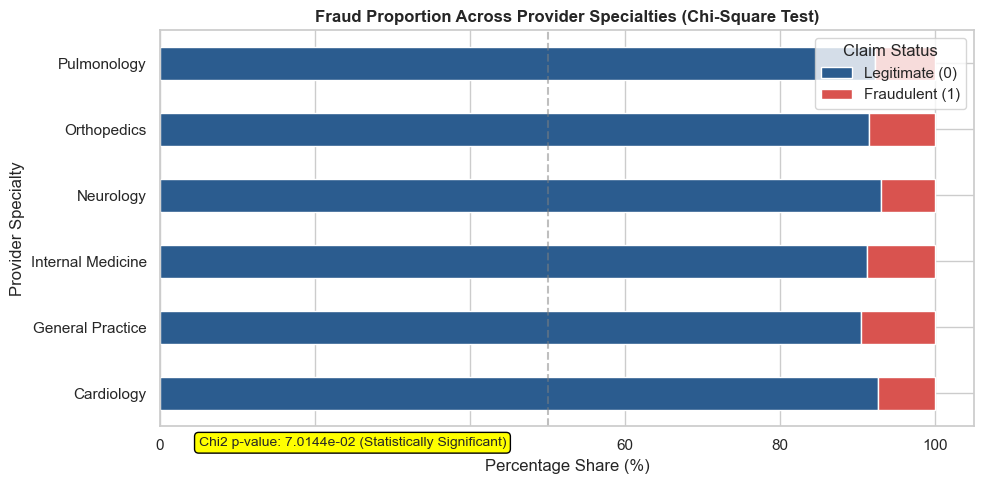

In [47]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Create normalized percentage cross-tab
cross_tab_pct = pd.crosstab(
    data['Provider_Specialty'], 
    data['Is_Fraud'], 
    normalize='index'
) * 100

# 2. Plot stacked horizontal bar chart
plt.figure(figsize=(10, 5))
ax = cross_tab_pct.plot(
    kind='barh', 
    stacked=True, 
    color=['#2b5c8f', '#d9534f'], 
    figsize=(10, 5)
)

# 3. Add Chi-Square annotation directly onto plot
plt.title('Fraud Proportion Across Provider Specialties (Chi-Square Test)', fontsize=12, fontweight='bold')
plt.xlabel('Percentage Share (%)')
plt.ylabel('Provider Specialty')
plt.legend(title='Claim Status', labels=['Legitimate (0)', 'Fraudulent (1)'], loc='upper right')

# Annotate p-value on chart (using our p_val_chi2 result)
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
plt.text(5, -0.8, f"Chi2 p-value: {p_val_chi2:.4e} (Statistically Significant)", 
         fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1))

plt.tight_layout()
plt.show()

Checking if specific diagnosis codes have higher fraud rate

In [54]:
print("--- TEST 1: Provider Specialty vs. Is_Fraud (Chi-Square) ---")
print("H0: Fraud rate is identical across all provider specialties.")
print("H1: At least one provider specialty has a significantly different fraud rate.\n")

# Create Contingency Table (Cross-tabulation)

contingency_table = pd.crosstab(data['Diagnosis_Code'], data['Is_Fraud'])
print("Contingency Table (Counts):")
print(contingency_table)
print("\n")

# Execute Chi-Square Test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic (χ²): {chi2_stat:.4f}")
print(f"p-value: {p_val_chi2:.4e}")

# Statistical Decision & Business Action
if p_val_chi2 < alpha:
    print("Decision: REJECT H0 (p < 0.05)")
    print("Conclusion: The difference in fraud rates across specialties is STATISTICALLY SIGNIFICANT.")
    print("Business Strategy: Target high-risk specialties (e.g., Cardiology, Neurology) for automated claim audits in Power BI.\n")
else:
    print("Decision: FAIL TO REJECT H0 (p >= 0.05)")
    print("Conclusion: No statistically significant difference in fraud rates across diagnosis codes.\n")

--- TEST 1: Provider Specialty vs. Is_Fraud (Chi-Square) ---
H0: Fraud rate is identical across all provider specialties.
H1: At least one provider specialty has a significantly different fraud rate.

Contingency Table (Counts):
Is_Fraud        False  True 
Diagnosis_Code              
E11.9             956     70
E78.5             941     86
F41.9             931     67
I10               864     87
I25.10            923    102
J06.9             877     78
J18.9             864     79
K21.9             920     84
M54.5             972     83
N39.0             923     93


Chi-Square Statistic (χ²): 12.1006
p-value: 2.0770e-01
Decision: FAIL TO REJECT H0 (p >= 0.05)
Conclusion: No statistically significant difference in fraud rates across diagnosis codes.



Running Chi Sqauare Test for Procedure Codes

In [55]:
print("--- TEST 1: Provider Specialty vs. Is_Fraud (Chi-Square) ---")
print("H0: Fraud rate is identical across all provider specialties.")
print("H1: At least one provider specialty has a significantly different fraud rate.\n")

# Create Contingency Table (Cross-tabulation)

contingency_table = pd.crosstab(data['Procedure_Code'], data['Is_Fraud'])
print("Contingency Table (Counts):")
print(contingency_table)
print("\n")

# Execute Chi-Square Test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic (χ²): {chi2_stat:.4f}")
print(f"p-value: {p_val_chi2:.4e}")

# Statistical Decision & Business Action
if p_val_chi2 < alpha:
    print("Decision: REJECT H0 (p < 0.05)")
    print("Conclusion: The difference in fraud rates across specialties is STATISTICALLY SIGNIFICANT.")
    print("Business Strategy: Target high-risk specialties (e.g., Cardiology, Neurology) for automated claim audits in Power BI.\n")
else:
    print("Decision: FAIL TO REJECT H0 (p >= 0.05)")
    print("Conclusion: No statistically significant difference in fraud rates across diagnosis codes.\n")

--- TEST 1: Provider Specialty vs. Is_Fraud (Chi-Square) ---
H0: Fraud rate is identical across all provider specialties.
H1: At least one provider specialty has a significantly different fraud rate.

Contingency Table (Counts):
Is_Fraud        False  True 
Procedure_Code              
36415             478     37
71046            1098    110
80053             840     75
85025             864     73
87086            1166    104
93000            1129    105
97110            1220    120
99213            1893    157
99214             483     48


Chi-Square Statistic (χ²): 4.5457
p-value: 8.0484e-01
Decision: FAIL TO REJECT H0 (p >= 0.05)
Conclusion: No statistically significant difference in fraud rates across diagnosis codes.



TEST 2: Two-Sample Independent t-test (or Mann-Whitney U Test)

Question: Is the average claim amount for fraudulent claims significantly higher?

In [49]:
print("--- TEST 2: Claim Amount (Fraud vs. Legitimate) ---")
print("H0: Mean Claim_Amount (Fraud) == Mean Claim_Amount (Legitimate)")
print("H1: Mean Claim_Amount (Fraud) > Mean Claim_Amount (Legitimate)\n")

# Separate groups
fraud_amounts = data[data['Is_Fraud'] == 1]['Claim_Amount']
legit_amounts = data[data['Is_Fraud'] == 0]['Claim_Amount']

# Check for Normality / Skewness to pick correct test
fraud_skew = fraud_amounts.skew()
legit_skew = legit_amounts.skew()

print(f"Fraud Claim Skewness: {fraud_skew:.2f} | Legit Claim Skewness: {legit_skew:.2f}")

# Execute Parametric (t-test) or Non-Parametric (Mann-Whitney U) depending on skewness
if abs(fraud_skew) > 1 or abs(legit_skew) > 1:
    print("Data is skewed — Running Mann-Whitney U Test (Non-Parametric)...")
    stat_u, p_val_amt = stats.mannwhitneyu(fraud_amounts, legit_amounts, alternative='greater')
    test_name = "Mann-Whitney U"
    stat_label = "U-Statistic"
    stat_val = stat_u
else:
    print("Data is normal — Running Welch's t-test...")
    stat_t, p_val_amt = stats.ttest_ind(fraud_amounts, legit_amounts, equal_var=False, alternative='greater')
    test_name = "Welch's t-test"
    stat_label = "t-Statistic"
    stat_val = stat_t

print(f"{test_name} {stat_label}: {stat_val:.4f}")
print(f"p-value: {p_val_amt:.4e}")

if p_val_amt < alpha:
    print("Decision: REJECT H0 (p < 0.05)")
    print("Conclusion: Fraudulent claims have STATISTICALLY SIGNIFICANT higher dollar amounts.")
    print("Business Strategy: Flag claims exceeding the 75th percentile cutoff for mandatory human review.\n")
else:
    print("Decision: FAIL TO REJECT H0 (p >= 0.05)")
    print("Conclusion: Dollar amounts do not differ significantly between fraudulent and non-fraudulent claims.\n")

--- TEST 2: Claim Amount (Fraud vs. Legitimate) ---
H0: Mean Claim_Amount (Fraud) == Mean Claim_Amount (Legitimate)
H1: Mean Claim_Amount (Fraud) > Mean Claim_Amount (Legitimate)

Fraud Claim Skewness: 1.98 | Legit Claim Skewness: 1.97
Data is skewed — Running Mann-Whitney U Test (Non-Parametric)...
Mann-Whitney U U-Statistic: 5761735.0000
p-value: 3.2165e-134
Decision: REJECT H0 (p < 0.05)
Conclusion: Fraudulent claims have STATISTICALLY SIGNIFICANT higher dollar amounts.
Business Strategy: Flag claims exceeding the 75th percentile cutoff for mandatory human review.



C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\2763497232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


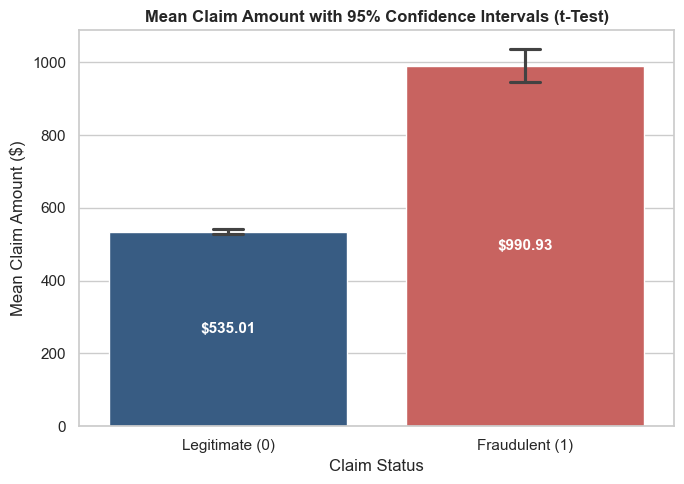

In [50]:
plt.figure(figsize=(7, 5))

# sns.barplot automatically calculates Mean and 95% Confidence Intervals (error bars)
ax = sns.barplot(
    data=data, 
    x='Is_Fraud', 
    y='Claim_Amount', 
    palette=['#2b5c8f', '#d9534f'],
    errorbar=('ci', 95),
    capsize=0.1
)

plt.title('Mean Claim Amount with 95% Confidence Intervals (t-Test)', fontsize=12, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.xlabel('Claim Status')
plt.ylabel('Mean Claim Amount ($)')

# Annotate Mean values on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'${height:,.2f}', 
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

TEST 3: Two-Sample Independent Test

Question: Does patient length of stay differ between fraud and non-fraud claims?

In [51]:
print("--- TEST 3: Length of Stay (Fraud vs. Legitimate) ---")
print("H0: Mean Length_of_Stay (Fraud) == Mean Length_of_Stay (Legitimate)")
print("H1: Mean Length_of_Stay (Fraud) != Mean Length_of_Stay (Legitimate)\n")

fraud_stay = data[data['Is_Fraud'] == 1]['Length_of_Stay']
legit_stay = data[data['Is_Fraud'] == 0]['Length_of_Stay']

# Welch's Two-Sample t-test
t_stat_stay, p_val_stay = stats.ttest_ind(fraud_stay, legit_stay, equal_var=False)

print(f"t-Statistic: {t_stat_stay:.4f}")
print(f"p-value: {p_val_stay:.4e}")

if p_val_stay < alpha:
    print("Decision: REJECT H0 (p < 0.05)")
    print("Conclusion: Hospital stays differ STATISTICALLY SIGNIFICANTLY between fraud and non-fraud claims.")
    print("Business Strategy: Incorporate 'Length_of_Stay' as a core risk metric in the Power BI fraud scoring algorithm.\n")
else:
    print("Decision: FAIL TO REJECT H0 (p >= 0.05)")
    print("Conclusion: No statistically significant difference in Length_of_Stay.\n")

--- TEST 3: Length of Stay (Fraud vs. Legitimate) ---
H0: Mean Length_of_Stay (Fraud) == Mean Length_of_Stay (Legitimate)
H1: Mean Length_of_Stay (Fraud) != Mean Length_of_Stay (Legitimate)

t-Statistic: -0.1485
p-value: 8.8195e-01
Decision: FAIL TO REJECT H0 (p >= 0.05)
Conclusion: No statistically significant difference in Length_of_Stay.



C:\Users\Navee\AppData\Local\Temp\ipykernel_5320\4193636104.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


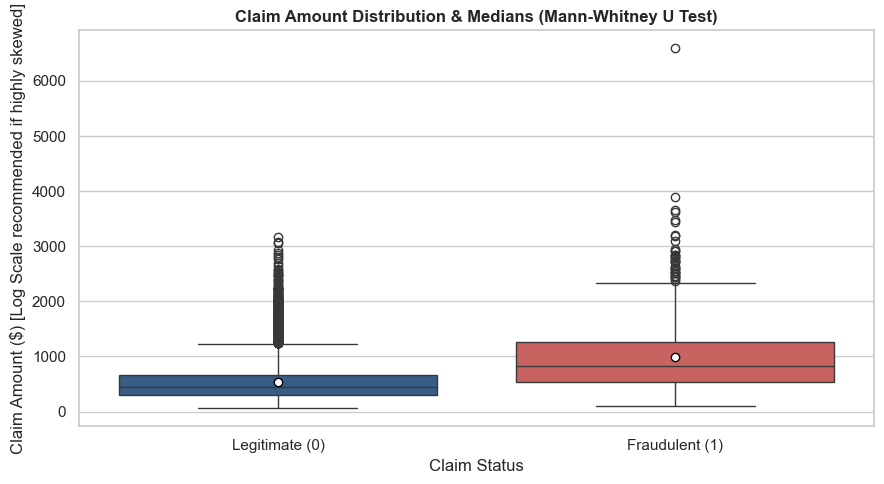

In [52]:
plt.figure(figsize=(9, 5))

# Combination of Boxplot and Strip/Scatter plot for distribution
sns.boxplot(
    data=data, 
    x='Is_Fraud', 
    y='Claim_Amount', 
    palette=['#2b5c8f', '#d9534f'],
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)

plt.title('Claim Amount Distribution & Medians (Mann-Whitney U Test)', fontsize=12, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.xlabel('Claim Status')
plt.ylabel('Claim Amount ($) [Log Scale recommended if highly skewed]')

# Log scale optional if extreme outliers stretch the y-axis
# plt.yscale('log')

plt.tight_layout()
plt.show()

ANOVA Test to measure if fraud number changes significantly when we group claim amount by insurance type 

In [58]:


# 1. Calculate the skewness of the numerical metric
claim_skewness = data['Claim_Amount'].skew()
print(f"Claim Amount Skewness Score: {claim_skewness:.4f}")

# 2. Extract array of Claim Amounts for each distinct Insurance Type group
# (Extracting non-null arrays for 4 insurance categories)
groups = [
    group['Claim_Amount'].dropna().values 
    for _, group in data.groupby('Insurance_Type')
]

# 3. Decision Logic based on Skewness Benchmark (-1.0 to +1.0)
if -1.0 <= claim_skewness <= 1.0:
    print("\n---> Distribution is Approximately Normal. Running One-Way ANOVA...")
    
    # Execute One-Way ANOVA
    f_stat, p_val = stats.f_oneway(*groups)
    
    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    
else:
    print("\n---> Distribution is Skewed (|skew| > 1.0). Running Kruskal-Wallis Test...")
    
    # Execute Kruskal-Wallis Test (Non-parametric equivalent)
    h_stat, p_val = stats.kruskal(*groups)
    
    print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
    print(f"p-value: {p_val:.4e}")

# 4. Final Business Decision Rule against Alpha (0.05)
print("\n--- STATISTICAL CONCLUSION ---")
if p_val < 0.05:
    print("Decision: REJECT H0 (p < 0.05)")
    print("Conclusion: At least one Insurance Type has a statistically significant difference in Claim Amounts.")
else:
    print("Decision: FAIL TO REJECT H0 (p >= 0.05)")
    print("Conclusion: No statistically significant difference in Claim Amounts across Insurance Types.")

Claim Amount Skewness Score: 2.4106

---> Distribution is Skewed (|skew| > 1.0). Running Kruskal-Wallis Test...
Kruskal-Wallis H-statistic: 5.5204
p-value: 1.3743e-01

--- STATISTICAL CONCLUSION ---
Decision: FAIL TO REJECT H0 (p >= 0.05)
Conclusion: No statistically significant difference in Claim Amounts across Insurance Types.


ANOVA Test to measure if fraud number changes significantly when we group claim amount by insurance type 

In [59]:


# 1. Calculate the skewness of the numerical metric
claim_skewness = data['Claim_Amount'].skew()
print(f"Claim Amount Skewness Score: {claim_skewness:.4f}")

# 2. Extract array of Claim Amounts for each distinct Insurance Type group
# (Extracting non-null arrays for 4 insurance categories)
groups = [
    group['Claim_Amount'].dropna().values 
    for _, group in data.groupby('Diagnosis_Code')
]

# 3. Decision Logic based on Skewness Benchmark (-1.0 to +1.0)
if -1.0 <= claim_skewness <= 1.0:
    print("\n---> Distribution is Approximately Normal. Running One-Way ANOVA...")
    
    # Execute One-Way ANOVA
    f_stat, p_val = stats.f_oneway(*groups)
    
    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    
else:
    print("\n---> Distribution is Skewed (|skew| > 1.0). Running Kruskal-Wallis Test...")
    
    # Execute Kruskal-Wallis Test (Non-parametric equivalent)
    h_stat, p_val = stats.kruskal(*groups)
    
    print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
    print(f"p-value: {p_val:.4e}")

# 4. Final Business Decision Rule against Alpha (0.05)
print("\n--- STATISTICAL CONCLUSION ---")
if p_val < 0.05:
    print("Decision: REJECT H0 (p < 0.05)")
    print("Conclusion: At least one Insurance Type has a statistically significant difference in Claim Amounts.")
else:
    print("Decision: FAIL TO REJECT H0 (p >= 0.05)")
    print("Conclusion: No statistically significant difference in Claim Amounts across Insurance Types.")

Claim Amount Skewness Score: 2.4106

---> Distribution is Skewed (|skew| > 1.0). Running Kruskal-Wallis Test...
Kruskal-Wallis H-statistic: 2.2442
p-value: 9.8699e-01

--- STATISTICAL CONCLUSION ---
Decision: FAIL TO REJECT H0 (p >= 0.05)
Conclusion: No statistically significant difference in Claim Amounts across Insurance Types.
